# Chapter 10 Exercise 1 Solution - Initial Parameters and Phase-Space Trajectories

This notebook uses SciBmad multi-turn tracking to study how the initial longitudinal momentum changes particle motion. It lists every selected particle's complete six-dimensional initial coordinates, plots the longitudinal $(z,p_z)$ phase-space trajectories, and applies a practical finite-turn boundedness test.

The main questions are:

1. Which initial conditions produce closed invariant curves?
2. Where is the stable fixed point?
3. Between which tested initial momenta does the motion change from bounded to unbounded?

In [1]:
using SciBmad
using CairoMakie
using Statistics
using Printf

## Ring model

We use the same compact 16-cell ring as the main Chapter 10 notebook. One RF cavity provides longitudinal focusing. The compact model makes it practical to track many turns interactively.

In [6]:
function build_long_term_tracking_ring(; n_cells=16, rf_voltage=2.0e6)
    elements = SciBmad.LineElement[]

    for i in 1:n_cells
        push!(elements, Quadrupole(name="QF_$i", L=0.25, Kn1=0.8))
        push!(elements, Drift(name="D1_$i", L=0.40))
        push!(elements, SBend(name="B_$i", L=1.0, angle=2pi / n_cells))
        push!(elements, Drift(name="D2_$i", L=0.40))
        push!(elements, Quadrupole(name="QD_$i", L=0.25, Kn1=-0.8))
        push!(elements, Drift(name="D3_$i", L=0.40))

        if i == n_cells
            push!(elements, RFCavity(name="RF", L=0.01, harmon=32, voltage=rf_voltage))
        end
    end

    return Beamline(elements; species_ref=Species("electron"), E_ref=3e9)
end

ring = build_long_term_tracking_ring()
circumference = sum(element.L for element in ring.line)
harmonic_number = 32

# Half the spacing between neighboring RF buckets is used as a practical z limit.
z_limit = circumference / (2harmonic_number)

@printf("Ring circumference = %.6f m\n", circumference)
@printf("Practical longitudinal bound |z| < %.6f m\n", z_limit)

Ring circumference = 43.210000 m
Practical longitudinal bound |z| < 0.675156 m


## Selected particle initial parameters

All particles begin on the transverse reference orbit, so $x=p_x=y=p_y=0$. We vary $z$ once to demonstrate that position offsets also generate invariant curves, and then scan $p_z$ through the transition between bounded and unbounded motion.

The selected values around $p_{z0}=0.0062$ and $0.0063$ are intentionally close together.

In [7]:
particle_labels = [
    "stable fixed point",
    "position offset",
    "inner invariant curve",
    "middle invariant curve",
    "large bounded curve",
    "last tested bounded",
    "first tested unbounded",
    "clearly unbounded",
]

# Columns are [x, px, y, py, z, pz].
initial_v = [
    0.0  0.0  0.0  0.0  0.00  0.0000
    0.0  0.0  0.0  0.0  0.10  0.0000
    0.0  0.0  0.0  0.0  0.00  0.0020
    0.0  0.0  0.0  0.0  0.00  0.0040
    0.0  0.0  0.0  0.0  0.00  0.0060
    0.0  0.0  0.0  0.0  0.00  0.0062
    0.0  0.0  0.0  0.0  0.00  0.0063
    0.0  0.0  0.0  0.0  0.00  0.0070
]

@printf("%-3s %-24s %9s %9s %9s %9s %9s %9s\n",
        "#", "description", "x", "px", "y", "py", "z", "pz")
for i in axes(initial_v, 1)
    @printf("%-3d %-24s %9.4f %9.4f %9.4f %9.4f %9.4f %9.4f\n",
            i, particle_labels[i], initial_v[i, :]...)
end

#   description                      x        px         y        py         z        pz
1   stable fixed point          0.0000    0.0000    0.0000    0.0000    0.0000    0.0000
2   position offset             0.0000    0.0000    0.0000    0.0000    0.1000    0.0000
3   inner invariant curve       0.0000    0.0000    0.0000    0.0000    0.0000    0.0020
4   middle invariant curve      0.0000    0.0000    0.0000    0.0000    0.0000    0.0040
5   large bounded curve         0.0000    0.0000    0.0000    0.0000    0.0000    0.0060
6   last tested bounded         0.0000    0.0000    0.0000    0.0000    0.0000    0.0062
7   first tested unbounded      0.0000    0.0000    0.0000    0.0000    0.0000    0.0063
8   clearly unbounded           0.0000    0.0000    0.0000    0.0000    0.0000    0.0070


## Multi-turn tracking and boundedness test

A finite numerical calculation cannot prove that a trajectory remains bounded forever. Here we use a practical test: after 1500 turns, the particle is classified as bounded if its maximum $|z|$ remains below half the RF-bucket spacing.

The complete history is stored as

```julia
history[particle, saved_turn, coordinate]
```

In [8]:
n_turns = 1500
history = track(ring, initial_v; n_turns=n_turns, save_every_n_turns=1)

max_abs_z = [maximum(abs.(history[i, :, 5])) for i in axes(history, 1)]
bounded = max_abs_z .< z_limit

@printf("%-3s %-24s %10s %12s\n", "#", "description", "max |z|", "classification")
for i in eachindex(particle_labels)
    @printf("%-3d %-24s %10.4f %12s\n",
            i, particle_labels[i], max_abs_z[i], bounded[i] ? "bounded" : "unbounded")
end

#   description                 max |z| classification
1   stable fixed point           0.0000      bounded
2   position offset              0.1006      bounded
3   inner invariant curve        0.1422      bounded
4   middle invariant curve       0.3026      bounded
5   large bounded curve          0.5560      bounded
6   last tested bounded          0.6160      bounded
7   first tested unbounded      55.9632    unbounded
8   clearly unbounded          105.5469    unbounded


## Longitudinal phase-space trajectories

Each point is the particle state sampled once per turn. For bounded particles, the points lie on closed invariant curves surrounding the stable fixed point at approximately $(z,p_z)=(0,0)$.

Unbounded trajectories are shown separately because their continuously drifting $z$ coordinate would make the bounded curves impossible to see on the same scale.

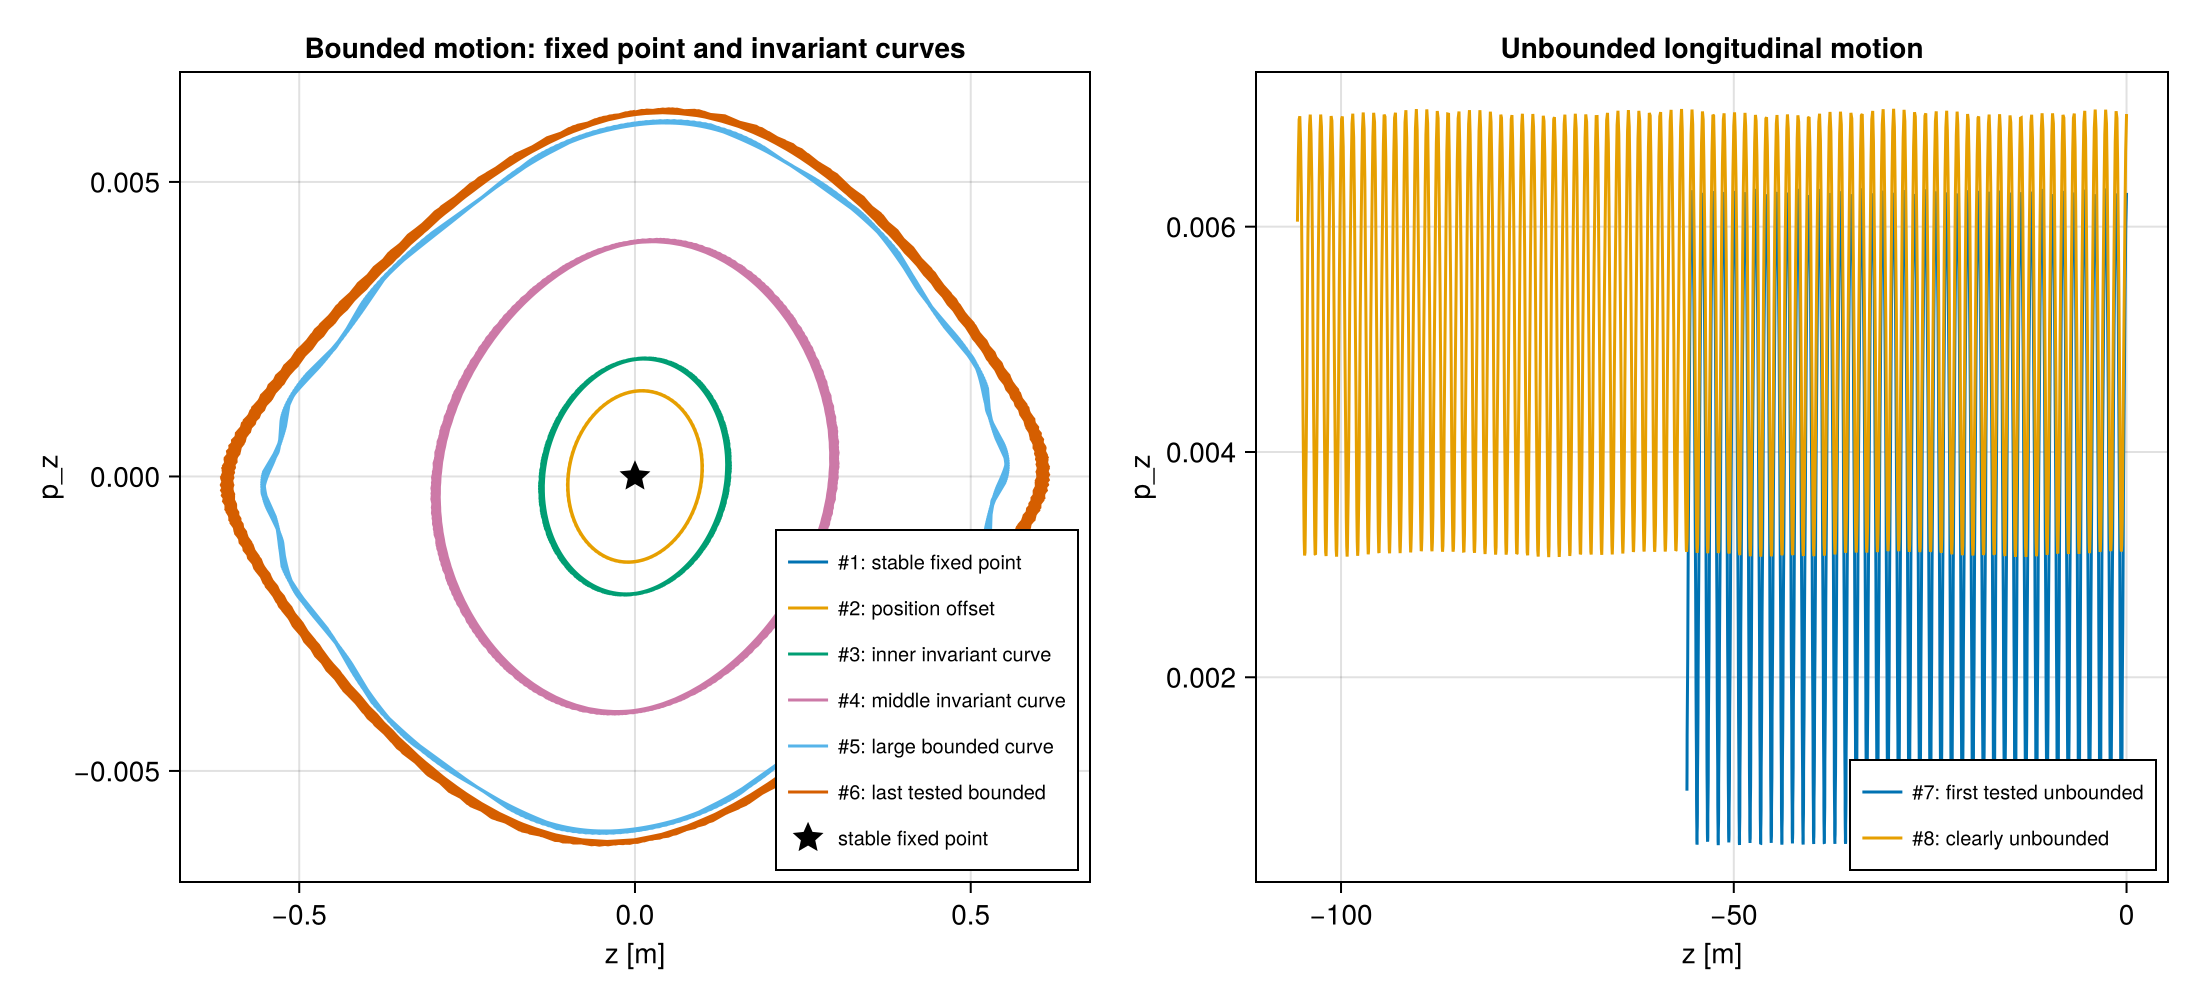

In [9]:
phase_figure = Figure(size=(1100, 500))

bounded_axis = Axis(
    phase_figure[1, 1];
    xlabel="z [m]",
    ylabel="p_z",
    title="Bounded motion: fixed point and invariant curves",
)

unbounded_axis = Axis(
    phase_figure[1, 2];
    xlabel="z [m]",
    ylabel="p_z",
    title="Unbounded longitudinal motion",
)

for i in eachindex(particle_labels)
    axis = bounded[i] ? bounded_axis : unbounded_axis
    lines!(axis, history[i, :, 5], history[i, :, 6]; linewidth=1.5, label="#$(i): $(particle_labels[i])")
end

# Mark the stable fixed point explicitly.
scatter!(bounded_axis, [0.0], [0.0]; color=:black, marker=:star5, markersize=18,
         label="stable fixed point")

axislegend(bounded_axis; position=:rb, labelsize=10)
axislegend(unbounded_axis; position=:rb, labelsize=10)
phase_figure

## Fine scan near the bounded-motion boundary

The selected particles suggest that the transition lies between $p_{z0}=0.0062$ and $0.0063$. The following scan repeats the boundedness test on a finer grid. This locates the transition for the chosen finite tracking time and criterion; it is not a mathematical proof of the exact separatrix.

Last bounded scan value:   pz0 = 0.0062750
First unbounded scan value: pz0 = 0.0063000


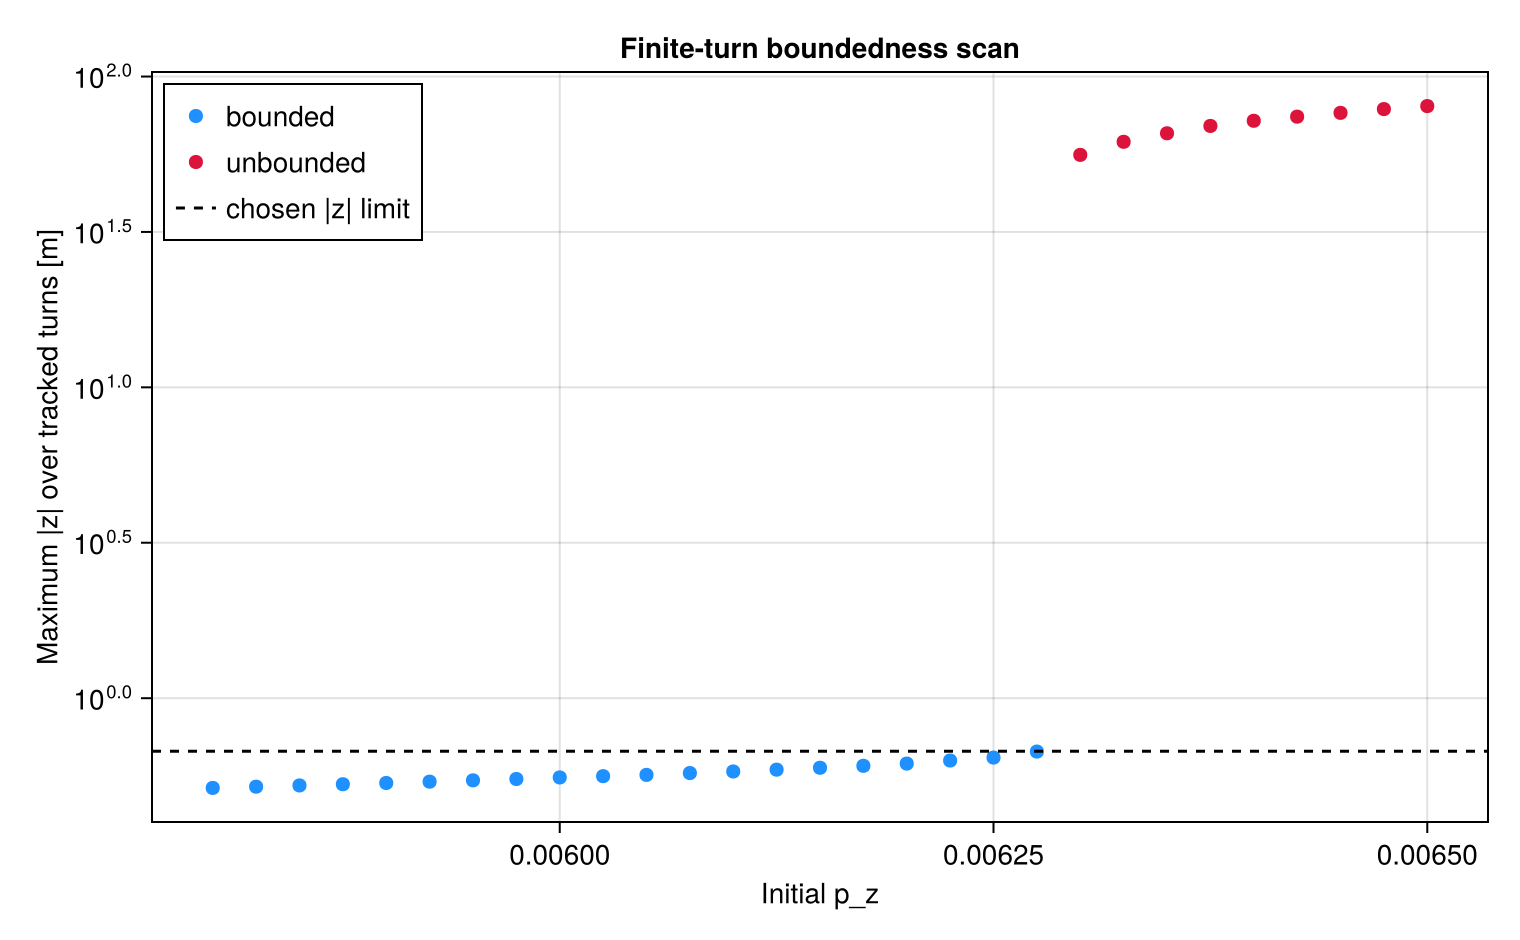

In [10]:
pz_scan = collect(range(0.0058, 0.0065; length=29))
scan_v0 = zeros(length(pz_scan), 6)
scan_v0[:, 6] .= pz_scan

scan_history = track(ring, scan_v0; n_turns=n_turns, save_every_n_turns=1)
scan_max_abs_z = [maximum(abs.(scan_history[i, :, 5])) for i in axes(scan_history, 1)]
scan_bounded = scan_max_abs_z .< z_limit

last_bounded_index = findlast(scan_bounded)
first_unbounded_index = findfirst(.!scan_bounded)

@printf("Last bounded scan value:   pz0 = %.7f\n", pz_scan[last_bounded_index])
@printf("First unbounded scan value: pz0 = %.7f\n", pz_scan[first_unbounded_index])

scan_figure = Figure(size=(760, 470))
scan_axis = Axis(
    scan_figure[1, 1];
    xlabel="Initial p_z",
    ylabel="Maximum |z| over tracked turns [m]",
    title="Finite-turn boundedness scan",
    yscale=log10,
)
scatter!(scan_axis, pz_scan[scan_bounded], scan_max_abs_z[scan_bounded];
         color=:dodgerblue, markersize=10, label="bounded")
scatter!(scan_axis, pz_scan[.!scan_bounded], scan_max_abs_z[.!scan_bounded];
         color=:crimson, markersize=10, label="unbounded")
hlines!(scan_axis, [z_limit]; color=:black, linestyle=:dash, label="chosen |z| limit")
axislegend(scan_axis; position=:lt)
scan_figure

## Interpretation

- Particle 1 remains at the stable fixed point: one complete turn maps it back to the same phase-space point.
- The other bounded particles trace closed invariant curves. The one-turn map moves each particle to another point on the same curve.
- As the initial $p_z$ increases, the invariant curves grow and become increasingly distorted by nonlinear motion.
- Between the last bounded and first unbounded tested values, the initial condition crosses the bounded-motion boundary associated with the longitudinal separatrix.
- Outside this boundary, $z$ drifts through successive RF buckets instead of oscillating around the stable fixed point.

Locating the unstable fixed point itself requires solving the one-turn fixed-point equation near the separatrix. This notebook identifies the stable fixed point and brackets the separatrix using tracked trajectories.